# What characteristics do popular climbing routes have in common?
**John Elliott Gorsuch and Victor Lee · SIADS 593 · exploratory analysis**

We study historical recorded climbing participation across the United States. Our three questions are:
1. How does popularity vary with climbing type and difficulty, keeping roped and bouldering grades separate?
2. How does the geographic distribution of participation differ between sport, trad and bouldering?
3. How do length, pitches, quality scores and recorded protection designations relate to popularity?

**Primary outcome:** absolute `sampled_tick_record_count` (archive records per route). There is **no minimum-tick filter**. Distinct sampled climbers provide a sensitivity comparison. A tick record is not necessarily a completed ascent, and ambiguous repeated records cannot be interpreted as confirmed repeat climbs.

This notebook is the analytical record. The course also requires a separate PDF report of at most 11 pages; the website is a companion, not a replacement for either deliverable.

## Motivation and related work
Climbers choose among routes that differ in difficulty, protection style, location and physical commitment. Recorded participation lets us investigate which profiles attract activity, while distinguishing popularity from quality and acknowledging who records climbs.

[Nick Wilder's 2014 Mountain Project tick analysis](https://www.rei.com/blog/uncategorized/factoid-4-most-popular-routes-by-difficulty) compared popular individual routes within difficulty grades. [RouteFinder by Present, Berger and Boland](https://jakepresent.github.io/RouteFinder/) mapped sport-climbing grades and explored descriptive route characteristics. These are useful precedents for grade and geographic comparisons. Our analysis combines tick-derived participation and structured route features, separates styles, and checks whether apparent relationships survive adjusted comparisons. We do not reproduce those studies or infer a representative census.

## Reproduce and inspect the sources
Install the pinned dependencies, then run:
```bash
python scripts/download.py
python scripts/build_main.py
```
This notebook builds the EDA outputs. `python scripts/eda.py` produces the same figures, tables and map exports outside Jupyter. `requirements-lock.txt` records the full installed environment.

The main table has **97,437 unique MP route IDs and 46 fields**. It combines Kaggle CSV features, historical JSON bouldering metadata, historical tick-derived CSV aggregates, and separate OpenBeta rating aggregates. The tick archive contains 2,115,034 rows for 47,002 users and 118,018 route IDs; it was committed April 21, 2019, with unknown individual observation dates. Source user histories were capped at 1,000 records.

The feature population was 199,083 routes. A strict inner join on MP ID retained 97,437 and dropped 101,646 without sample records. Subsequent metadata/rating left joins preserved that population. Matching uses IDs rather than guessed names or coordinates. Missing values remain missing. See [source access details](../docs/sources.md), [join implementation](../docs/main_dataset.md), [field definitions](../docs/data_dictionary.md), and checksummed [source manifest](../reports/source_manifest.json). Public availability does not establish a license for the original tick archive, which declares none. Only aggregates are published; no user identifiers are in the analytical table.

In [1]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path.cwd() if (Path.cwd() / "scripts").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT / "scripts"))
import eda

raw = pd.read_parquet(ROOT / "data/processed/climbing_routes_main.parquet")
assert raw.mp_route_id.is_unique
assert raw.sampled_tick_record_count.ge(1).all()
assert not {"UserID", "users", "comment", "tick_count"}.intersection(raw.columns)
display(pd.DataFrame({"rows": [len(raw)], "columns": [raw.shape[1]], "unique_route_ids": [raw.mp_route_id.nunique()]}))
raw[["route_name", "state", "rating_raw", "route_type", "sampled_tick_record_count"]].head()

,rows,columns,unique_route_ids
0,97437,46,97437


,route_name,state,rating_raw,route_type,sampled_tick_record_count
0,Garden Party,South Dakota,5.8,"Trad, TR",31
1,Paperboy Centerfold,South Dakota,5.8,"Trad, TR",35
2,Blockhead,South Dakota,5.1,"Sport, TR",17
3,Central Yellow Wall,South Dakota,V3 R,"TR, Boulder",6
4,Wiessner Chimney,South Dakota,5.6,Trad,11


## Cleaning decisions and the analysis population
We keep the complete joined dataset intact and create documented analysis fields:
- Exclude any ice, aid or snow flag from the core rock comparisons; summarize those records separately. Other/top-rope-only records are also outside the three-style comparison.
- Among core rock routes, **trad takes precedence**, then bouldering, then sport. Mixed trad/sport routes therefore belong to trad.
- Use textual grade families (`5.10`, `V2`), not decimal arithmetic. Letter/suffix grades are grouped by their major family. V ranges use the lower bound; V-easy/VB form a separate category.
- The source contains ambiguous `5.1` grades. For these cases only, an archived `5.1` or `5.10` family resolves the analysis family with an audit flag. Other cases remain unresolved. Original grade fields never change. Historical resolution is a sensitivity assumption because feature dates differ.
- Preserve missing lengths, pitch counts, quality scores and protection labels. **Not recorded does not mean safe.**
- Log-transform counts as `log(1 + count)` for regression/diagnostics and positive lengths/pitches as natural logs. Model and PCA complete-case filters apply only to those analyses.
- Flag coordinates outside a broad U.S. latitude/longitude envelope as implausible; omit them only from maps. This is an outlier check, not a validation of exact route locations.

In [2]:
data = eda.prepare_routes(raw)
core = data.loc[data.in_core_rock].copy()
tables = eda.create_tables(data)
display(tables["type_summary"])
display(tables["grade_audit"])
display(tables["missingness"].set_index("analysis_type").map(lambda value: f"{value:.1%}"))
assert len(data) == len(raw)
assert len(core) == 96735
assert core.ticks.eq(core.sampled_tick_record_count).all()
data.loc[~data.analysis_map_valid, ["route_name", "state", "area_latitude", "area_longitude"]]

,analysis_type,routes,total_ticks,mean_ticks,median_ticks,total_route_climber_pairs,mean_climbers,median_climbers
0,Bouldering,26530,206189,7.771919,2.0,193272,7.285036,2.0
1,Excluded: ice/aid/snow,630,13209,20.966667,3.0,11946,18.961905,2.0
2,Other rock / top rope,72,312,4.333333,3.0,283,3.930556,2.0
3,Sport,36856,952999,25.857364,7.0,849667,23.053695,6.0
4,Trad,33349,780188,23.394645,4.0,677417,20.312963,4.0


,analysis_grade_status,routes,total_ticks,mean_ticks,median_ticks,total_route_climber_pairs,mean_climbers,median_climbers
0,ambiguous source 5.1; unresolved,29,271,9.344828,2.0,234,8.068966,2.0
1,historical family resolves ambiguous 5.1,1604,30029,18.721322,4.0,27039,16.857232,4.0
2,source grade family,95804,1922597,20.068024,4.0,1705312,17.800008,4.0


,length_feet,pitches,average_stars,analysis_grade_family,protection_rating
analysis_type,,,,,
Bouldering,99.8%,97.1%,99.8%,0.0%,94.7%
Sport,12.7%,0.0%,0.1%,0.0%,97.1%
Trad,11.7%,0.1%,0.5%,1.2%,84.0%


,route_name,state,area_latitude,area_longitude
36079,Army Ant,California,-38.3675,145.1195


The core population has 36,856 sport, 33,349 trad and 26,530 bouldering routes. The analysis documents 630 ice/aid/snow routes and 72 other/top-rope-only routes separately. There are 1,604 archive-supported grade-family resolutions and 29 unresolved ambiguous cases. One California route has coordinates in Australia; its counts remain in non-spatial summaries, but it is omitted from maps. Some source state labels also disagree with otherwise plausible U.S. coordinates (for example, Colorado-labeled routes located in California). State summaries/filtering use source labels; maps use source coordinates. These discrepancies remain unresolved and limit fine geographic interpretation.

Most bouldering lengths and pitch counts are unavailable. We therefore do not pretend to compare boulder length with roped length or impute all boulders to one pitch. The join-retention report describes the pre-join population; core style counts describe a later, different filter.

,input_routes,retained_routes,dropped_routes,retained_percent
state,,,,
California,36115,18611,17504,51.532604
Colorado,30202,15856,14346,52.499834
Utah,16049,8769,7280,54.638918
Arizona,12245,5565,6680,45.447121
Washington,9495,3767,5728,39.673512
New Hampshire,5491,3161,2330,57.566928
New Mexico,5577,2984,2593,53.505469
Wyoming,6600,2840,3760,43.030303
Nevada,5678,2622,3056,46.178232


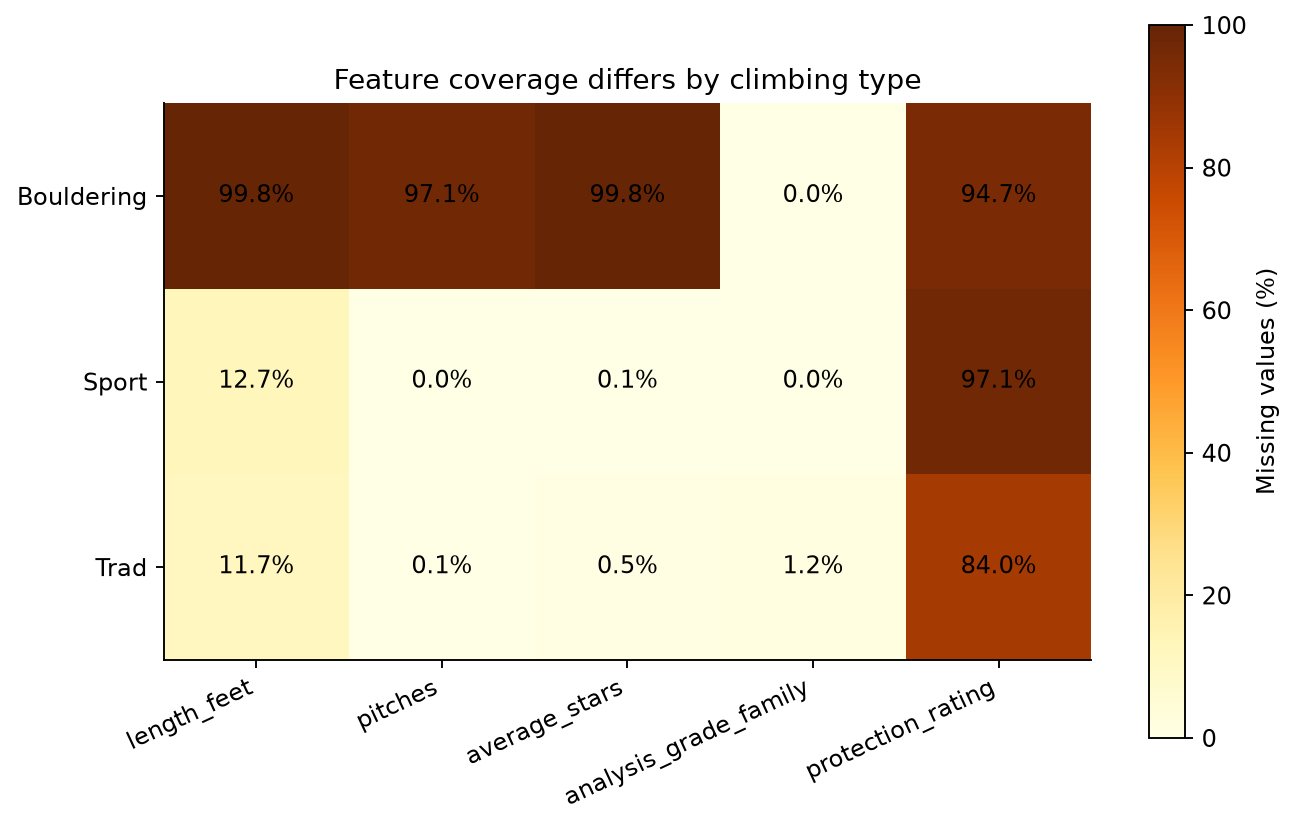

In [3]:
coverage = pd.read_csv(ROOT / "reports/main_join_coverage.csv")
state_coverage = coverage.groupby("state")[["input_routes", "retained_routes", "dropped_routes"]].sum()
state_coverage["retained_percent"] = 100 * state_coverage.retained_routes / state_coverage.input_routes
display(state_coverage.sort_values("retained_routes", ascending=False).head(15))
eda.create_plots(data, tables)
eda.additional_plots(data)

def show_figure(name, width=950):
    display(Image(filename=str(eda.OUT / f"{name}.png"), width=width))

show_figure("05_missingness")

## Recorded popularity: distribution and repeated records
Figure 1 compares the count distributions with logarithmic axes so the long tail remains visible. Figure 2 compares ticks with distinct climbers. Values above the diagonal reflect repeated user-route records, including unresolved collection duplicates. Counts are positive because the inner join excludes unobserved routes; absence from this sample is not zero real-world activity.

,count,mean,std,min,50%,90%,95%,99%,max
analysis_type,,,,,,,,,
Bouldering,26530.0,7.771919,19.855958,1.0,2.0,17.0,32.0,86.0,559.0
Sport,36856.0,25.857364,60.012131,1.0,7.0,64.0,114.0,289.0,1486.0
Trad,33349.0,23.394645,72.738695,1.0,4.0,51.0,99.0,327.0,2409.0


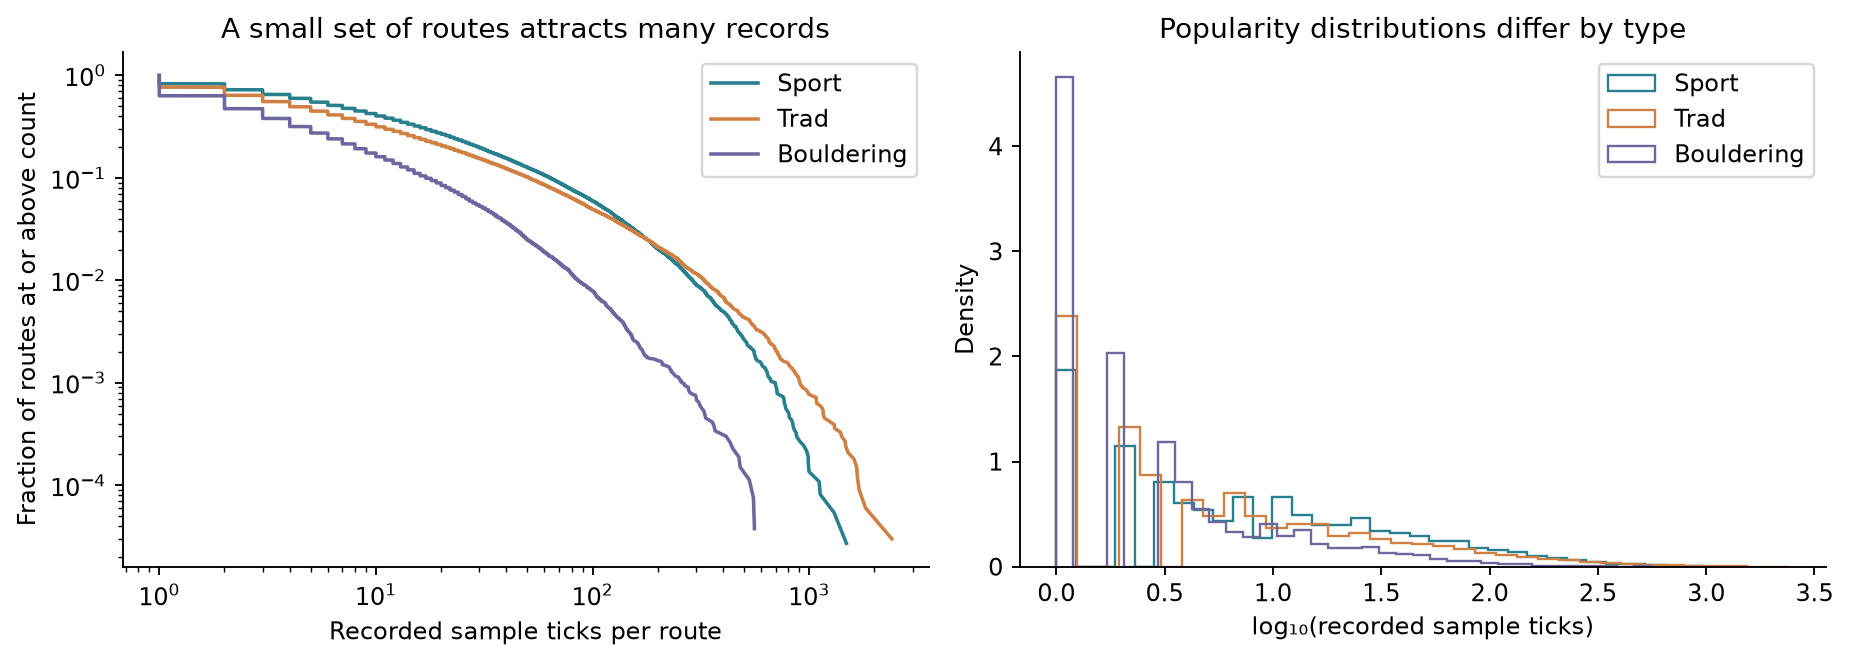

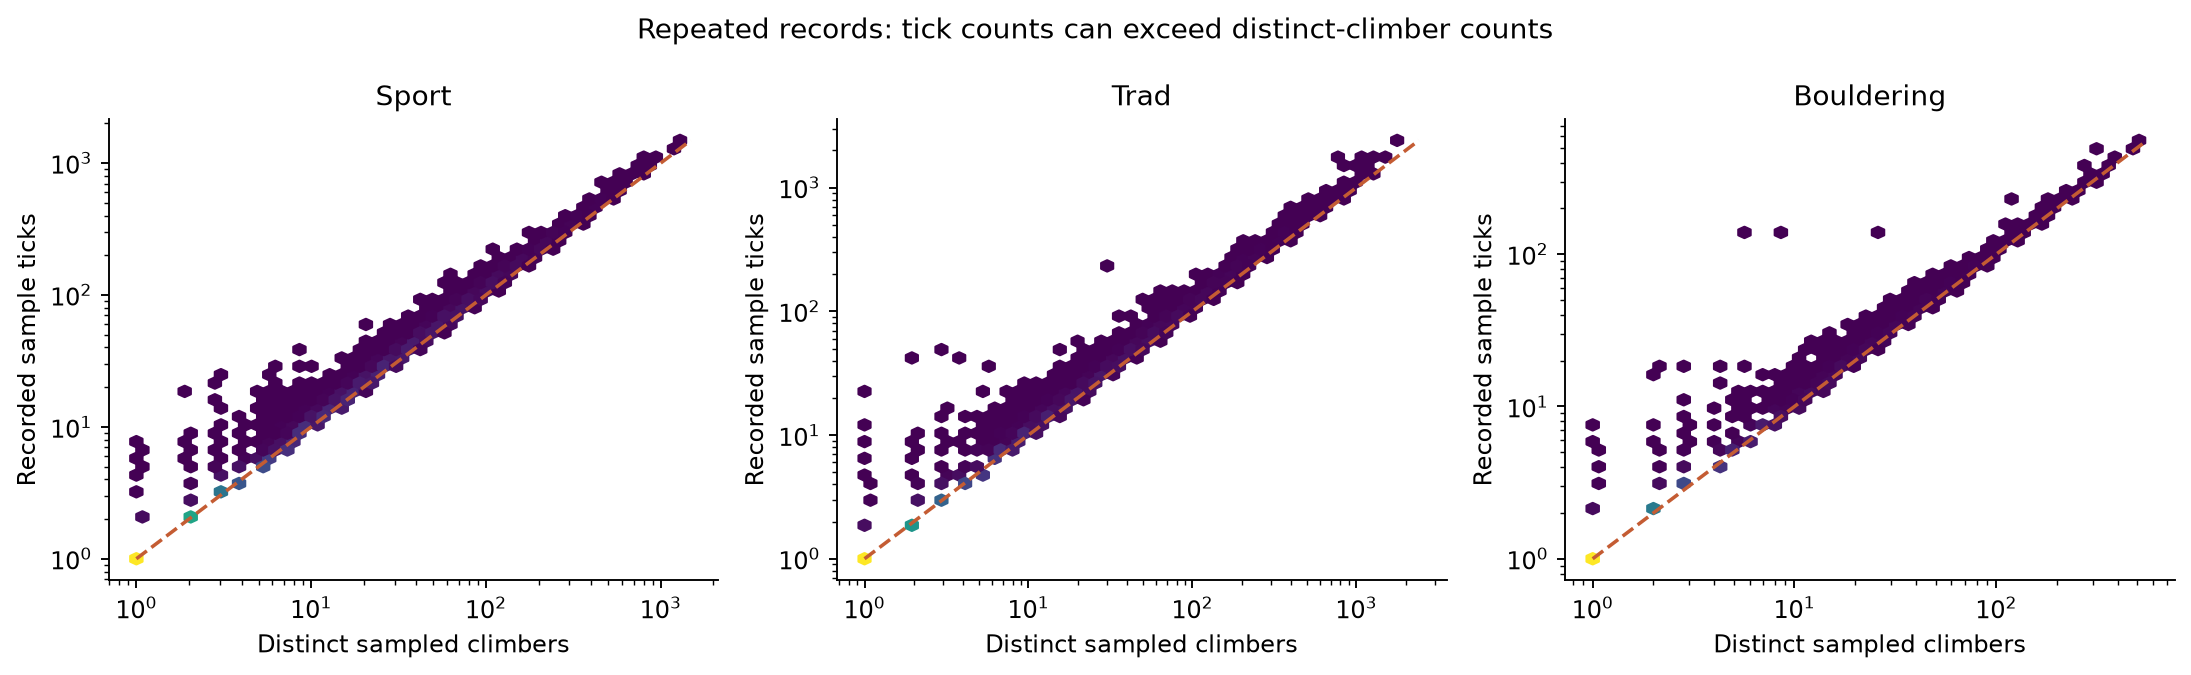

In [4]:
display(core.groupby("analysis_type")["ticks"].describe(percentiles=[.5, .9, .95, .99]))
show_figure("01_tick_distribution")
show_figure("06_ticks_vs_climbers")

## Question 1 — Which grade families are most popular?
We present both **total sample ticks** and **mean ticks per route**. The first measures recorded activity volume; the second divides by route availability in the retained sample. Neither adjusts for route age, access or reporting exposure. `5.10` combines its letter subgrades, so it is a coarse family rather than one precise difficulty.

All groups appear in the descriptive figure. To avoid choosing a highest mean from a handful of routes, the summary below requires **30 routes per grade group** when ranking means; this is not a tick threshold. Route counts and medians accompany those means.

,style,highest_total_grade,total_ticks,routes_in_total_grade,highest_mean_grade_ge30_routes,mean_ticks,median_ticks,routes_in_mean_grade
0,Sport,5.10,310717,10923,5.7,47.314750,17.0,1722
1,Trad,5.10,163711,8542,5.6,36.874712,6.0,2171
2,Bouldering,V0,36701,4435,V1,8.278192,2.0,3893


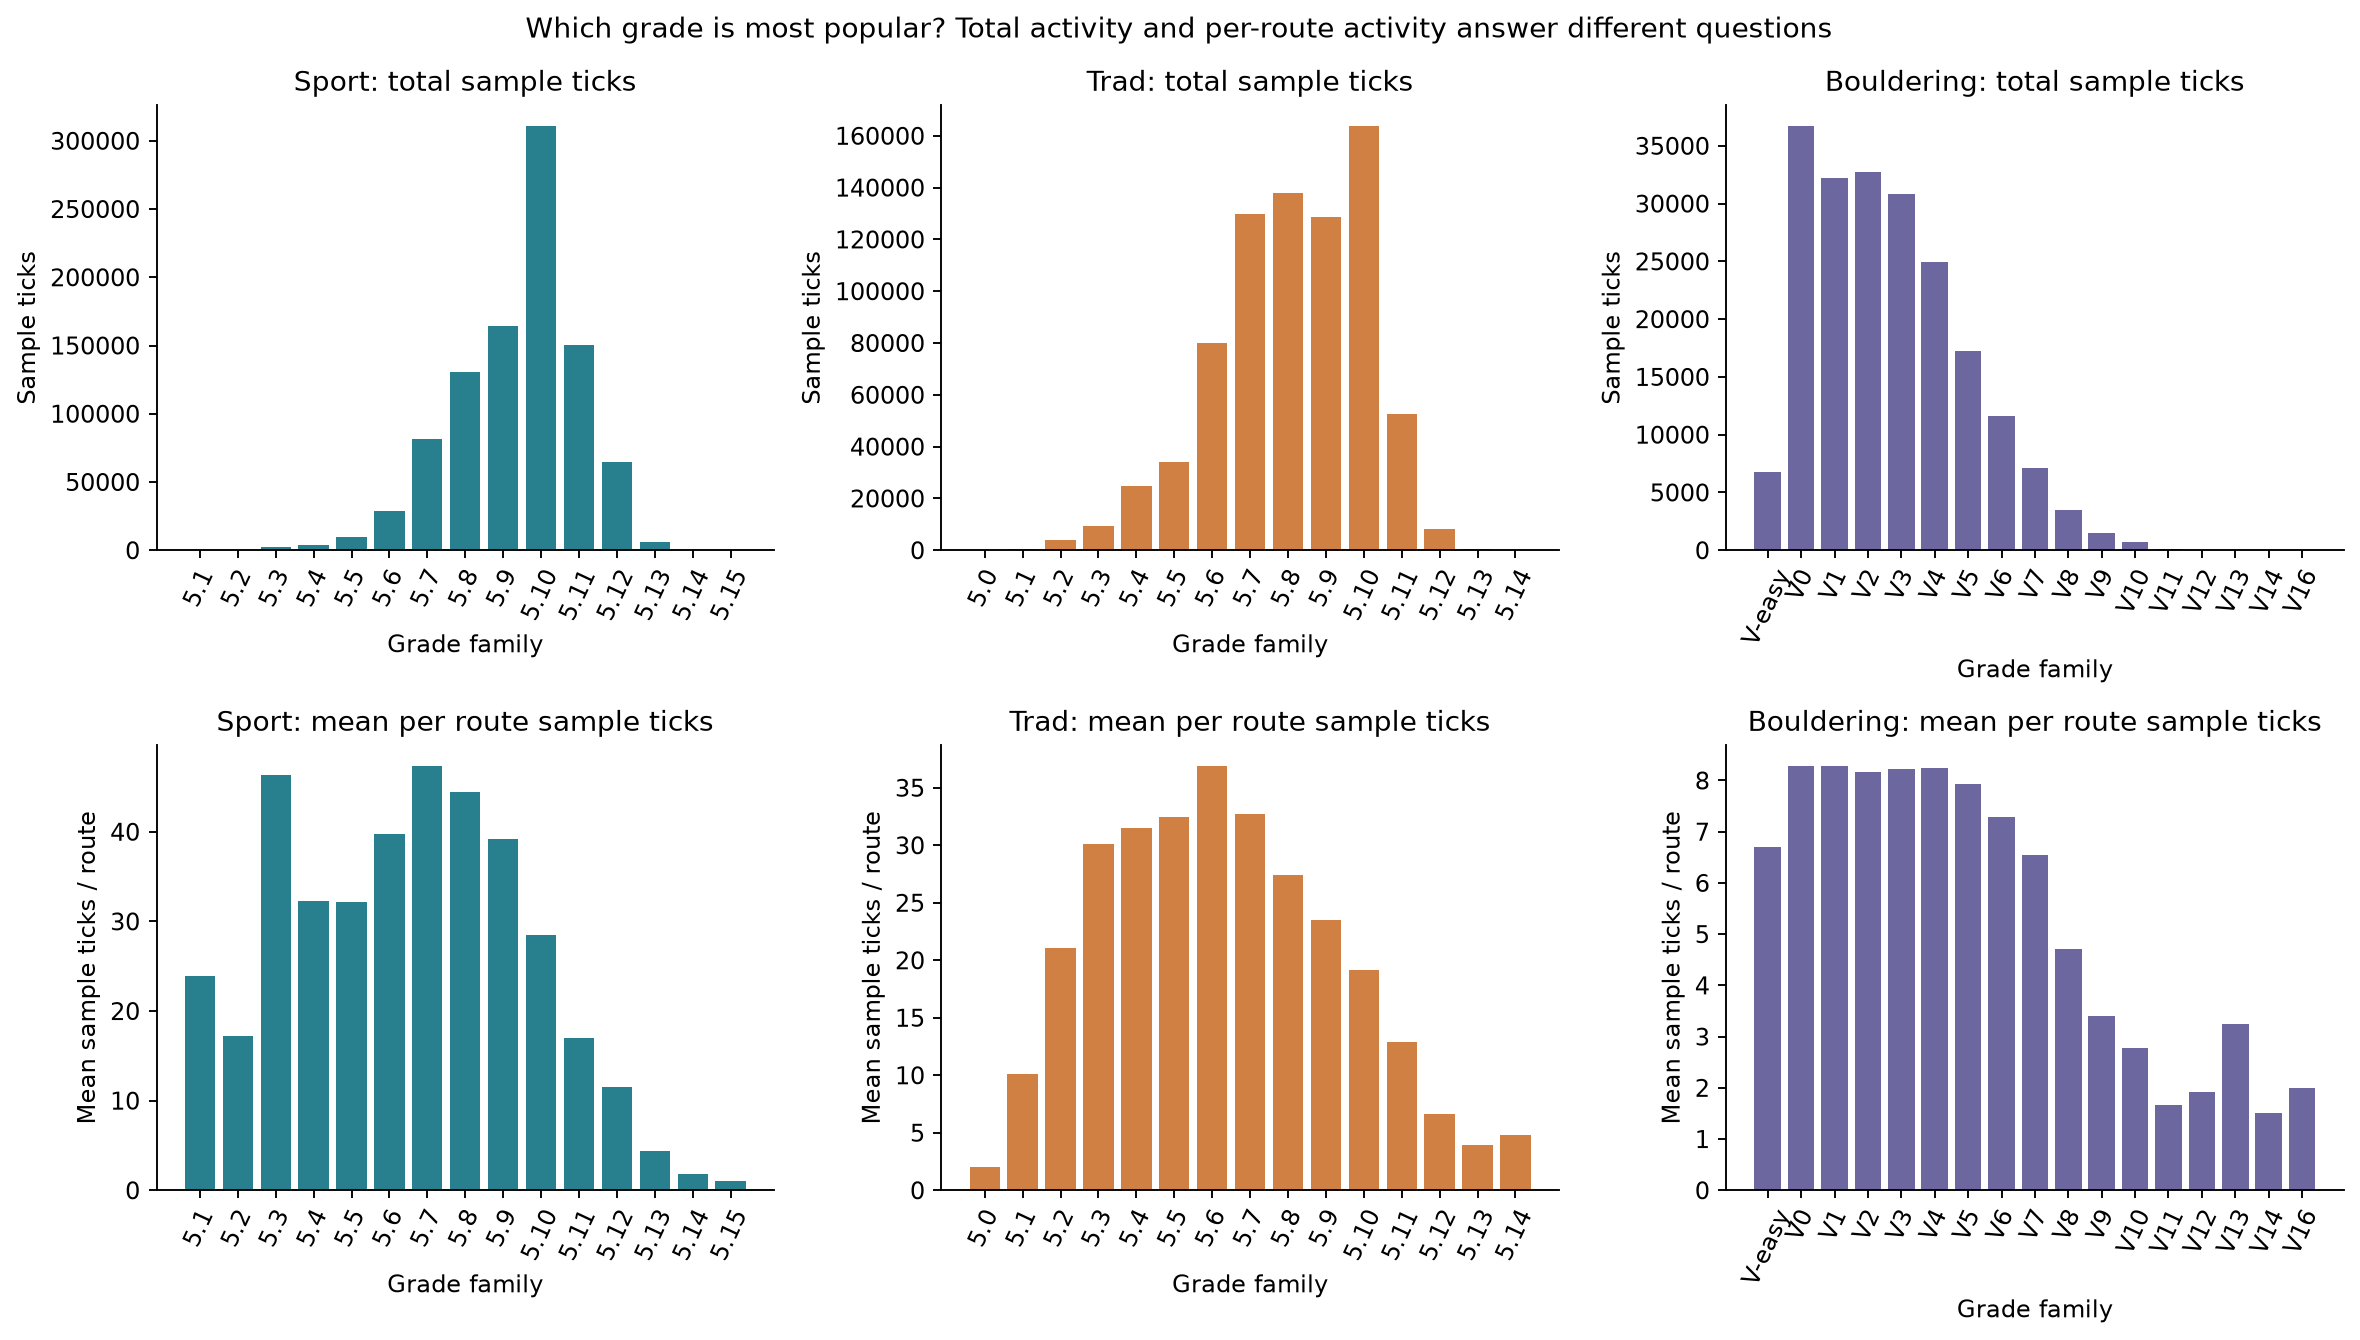

In [5]:
grades = tables["grade_summary"].dropna(subset=["analysis_grade_family"])
winners = []
for kind in eda.COLORS:
    part = grades.loc[grades.analysis_type.eq(kind)]
    volume = part.loc[part.total_ticks.idxmax()]
    supported = part.loc[part.routes.ge(30)]
    average = supported.loc[supported.mean_ticks.idxmax()]
    winners.append({"style": kind, "highest_total_grade": volume.analysis_grade_family,
                    "total_ticks": int(volume.total_ticks), "routes_in_total_grade": int(volume.routes),
                    "highest_mean_grade_ge30_routes": average.analysis_grade_family,
                    "mean_ticks": average.mean_ticks, "median_ticks": average.median_ticks,
                    "routes_in_mean_grade": int(average.routes)})
display(pd.DataFrame(winners))
show_figure("02_grade_popularity")

**Finding:** 5.10 leads total tick records for both sport (310,717) and trad (163,711). V0 leads bouldering (36,701). Per-route means peak at 5.7 for sport and 5.6 for trad among groups with at least 30 routes. Bouldering V0–V4 means are very close: the numerical V1 lead is not a persuasive separation on its own. Changing the observation threshold changes some mean leaders, as the sensitivity section shows.

## Question 2 — How does recorded activity vary geographically?
State tables and Figure 4 distinguish tick volume from style share. Figure 5 shows fixed 0.2° coordinate cells for the contiguous U.S., with a common color scale across the three styles. These cells are **not equal-area density estimates**, and coordinates describe climbing areas rather than precise route positions. Alaska and Hawaii remain in nationwide tables and the interactive atlas.

The companion atlas supports state, style, grade, protection, length and name filters; total/mean ticks, route count, route–climber pairs and dominant-style map layers; cell inspection; and filtered CSV export. Summing distinct climbers across routes counts participation pairs, not unique people in an area.

,routes,ticks,mean_ticks_per_route
state,,,
Colorado,15735,386042,24.533969
California,18487,370612,20.047168
Utah,8584,207597,24.18418
Nevada,2615,115356,44.113193
Kentucky,1671,90295,54.036505
New Hampshire,3148,80927,25.707433
Arizona,5520,72106,13.062681
Washington,3725,69062,18.540134
New York,2051,68578,33.436373


analysis_type,Bouldering,Sport,Trad
state,,,
Colorado,6.6,57.1,36.2
California,16.3,32.5,51.2
Utah,10.1,45.3,44.6
Nevada,8.1,54.7,37.2
Kentucky,0.1,86.1,13.8
New Hampshire,14.3,62.8,22.9
Arizona,6.4,62.0,31.5
Washington,7.7,48.2,44.1
New York,4.8,2.9,92.4


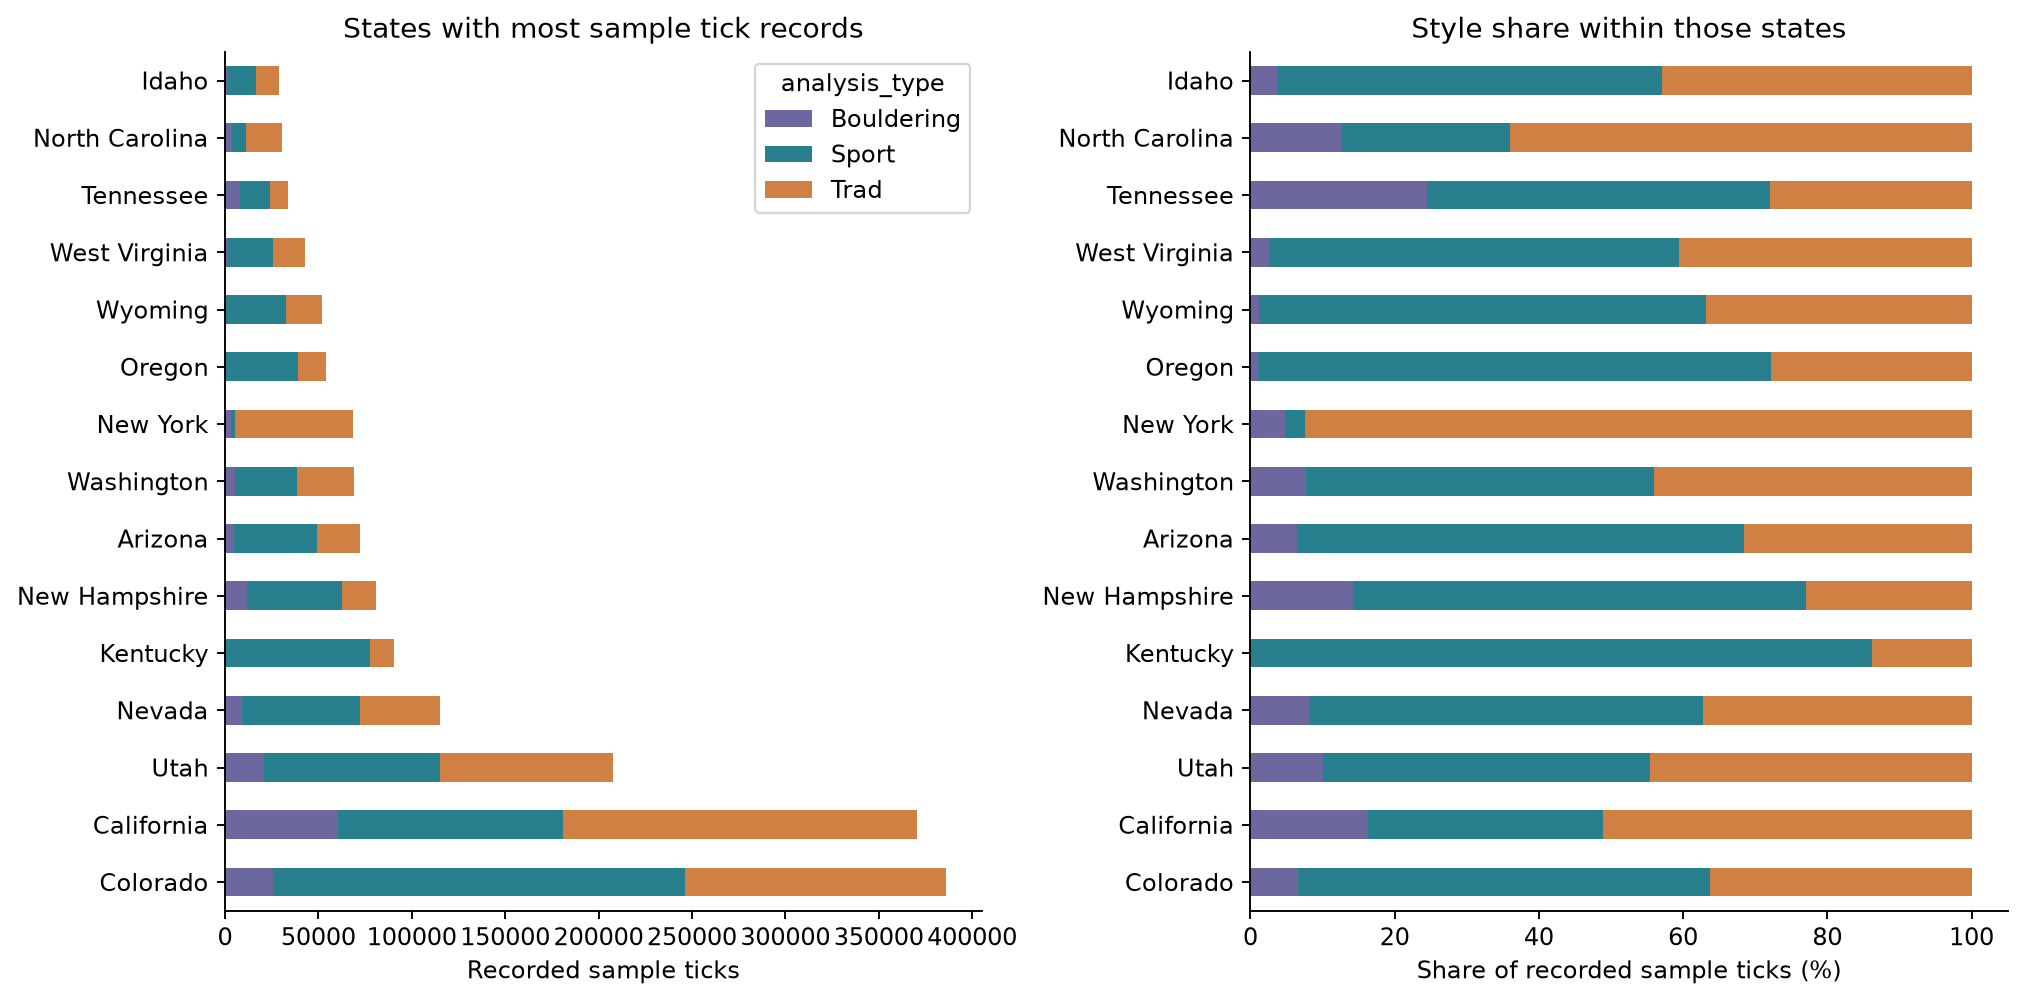

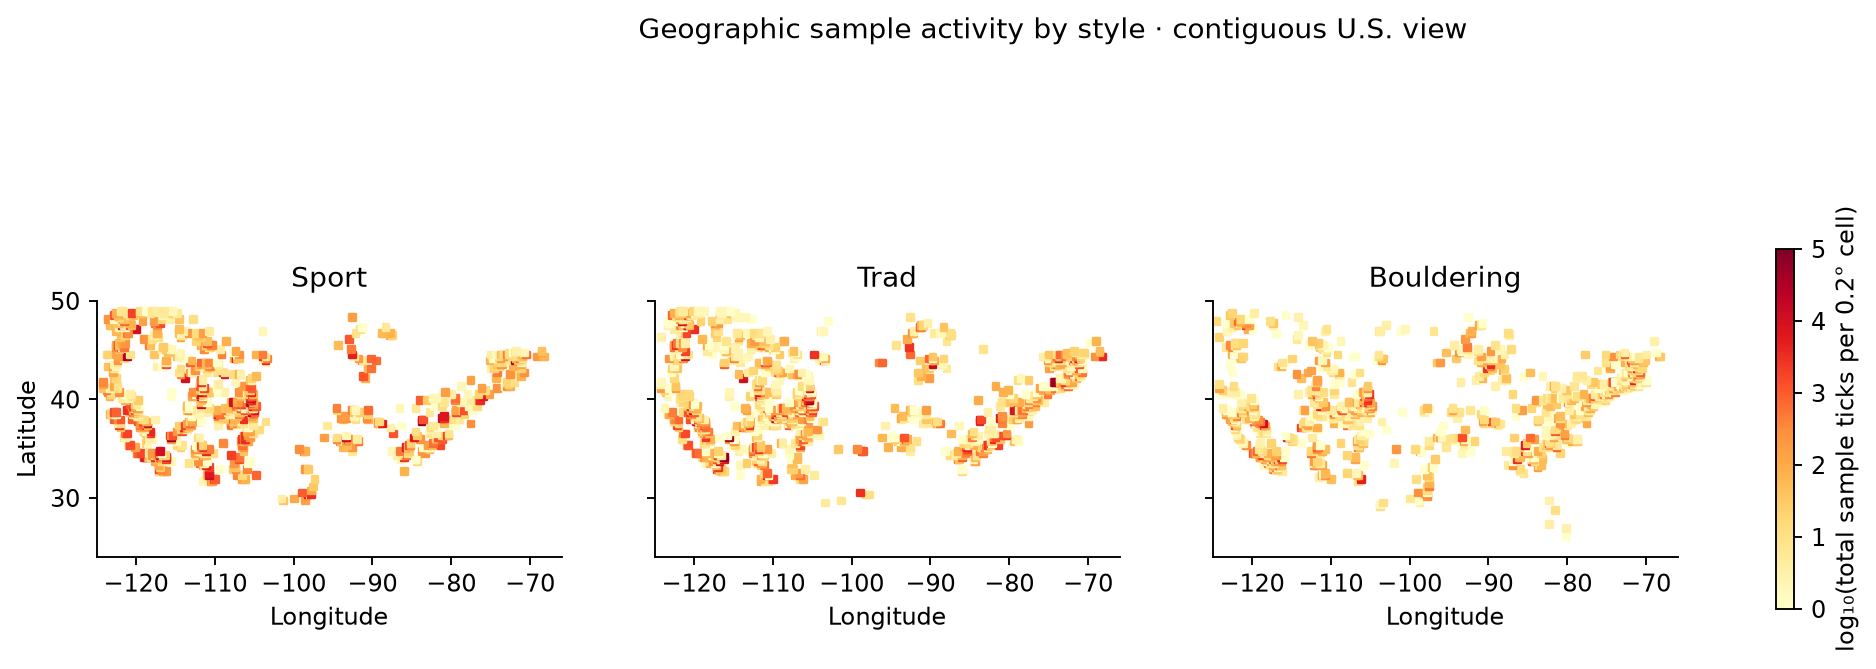

In [6]:
state_types = tables["state_type_summary"]
state_totals = state_types.groupby("state").agg(routes=("routes", "sum"), ticks=("total_ticks", "sum"))
state_totals["mean_ticks_per_route"] = state_totals.ticks / state_totals.routes
display(state_totals.sort_values("ticks", ascending=False).head(15))
state_shares = state_types.pivot(index="state", columns="analysis_type", values="total_ticks").fillna(0)
display((state_shares.div(state_shares.sum(axis=1), axis=0) * 100).round(1).loc[state_totals.nlargest(15, "ticks").index])
show_figure("03_state_styles")
show_figure("12_geographic_ticks")

Large regional totals can reflect route availability and participation/reporting patterns. We should not label an area intrinsically more popular from totals alone. The tables allow comparisons within climbing type and grade family, and the coverage table shows where the inner join retained relatively little information.

## Question 3 — Which characteristics relate to popularity?
Figure 6 compares recorded length bands and protection categories. Interpret these as unadjusted comparisons, with denominators and missingness shown in the tables. Sparse long sport-route groups can have unstable means. Protection groups compare recorded labels; the reference does not establish safety.

Figure 7 provides pairwise Spearman associations among sport/trad features and log ticks. Pairwise available cases are used, and a separate matrix records each pair's sample size. These correlations do not hold geography, difficulty or type constant.

,analysis_type,length_band,routes,total_ticks,mean_ticks,median_ticks,total_route_climber_pairs,mean_climbers,median_climbers
0,Bouldering,≤30,27,648,24.000000,4.0,518,19.185185,4.0
1,Bouldering,31–60,23,284,12.347826,4.0,260,11.304348,4.0
2,Bouldering,61–100,3,120,40.000000,49.0,100,33.333333,44.0
3,Bouldering,NaN,26477,205137,7.747743,2.0,192394,7.266458,2.0
4,Sport,≤30,2387,41398,17.343109,6.0,36974,15.489736,6.0
5,Sport,31–60,16584,396357,23.899964,7.0,354850,21.397130,6.0
6,Sport,61–100,11090,324736,29.281876,7.0,289266,26.083499,6.0
7,Sport,101–150,1287,31146,24.200466,6.0,27409,21.296814,5.0
8,Sport,151–300,642,18590,28.956386,9.0,16456,25.632399,8.0
9,Sport,301–600,161,6754,41.950311,10.0,5912,36.720497,9.0


,analysis_type,protection_group,routes,total_ticks,mean_ticks,median_ticks,total_route_climber_pairs,mean_climbers,median_climbers
0,Bouldering,Not recorded,25127,196423,7.817209,2.0,184312,7.335217,2.0
1,Bouldering,PG-13,962,5913,6.146570,2.0,5561,5.780665,2.0
2,Bouldering,R,377,3585,9.509284,2.0,3148,8.350133,2.0
3,Bouldering,X,64,268,4.187500,2.0,251,3.921875,1.5
4,Sport,Not recorded,35785,938276,26.219813,7.0,836291,23.369876,6.0
5,Sport,PG-13,751,10913,14.531292,4.0,9891,13.170439,4.0
6,Sport,R,294,3646,12.401361,3.0,3325,11.309524,3.0
7,Sport,X,26,164,6.307692,2.0,160,6.153846,2.0
8,Trad,Not recorded,28023,712532,25.426685,5.0,617930,22.050815,5.0
9,Trad,PG-13,2782,33787,12.144860,3.0,29991,10.780374,3.0


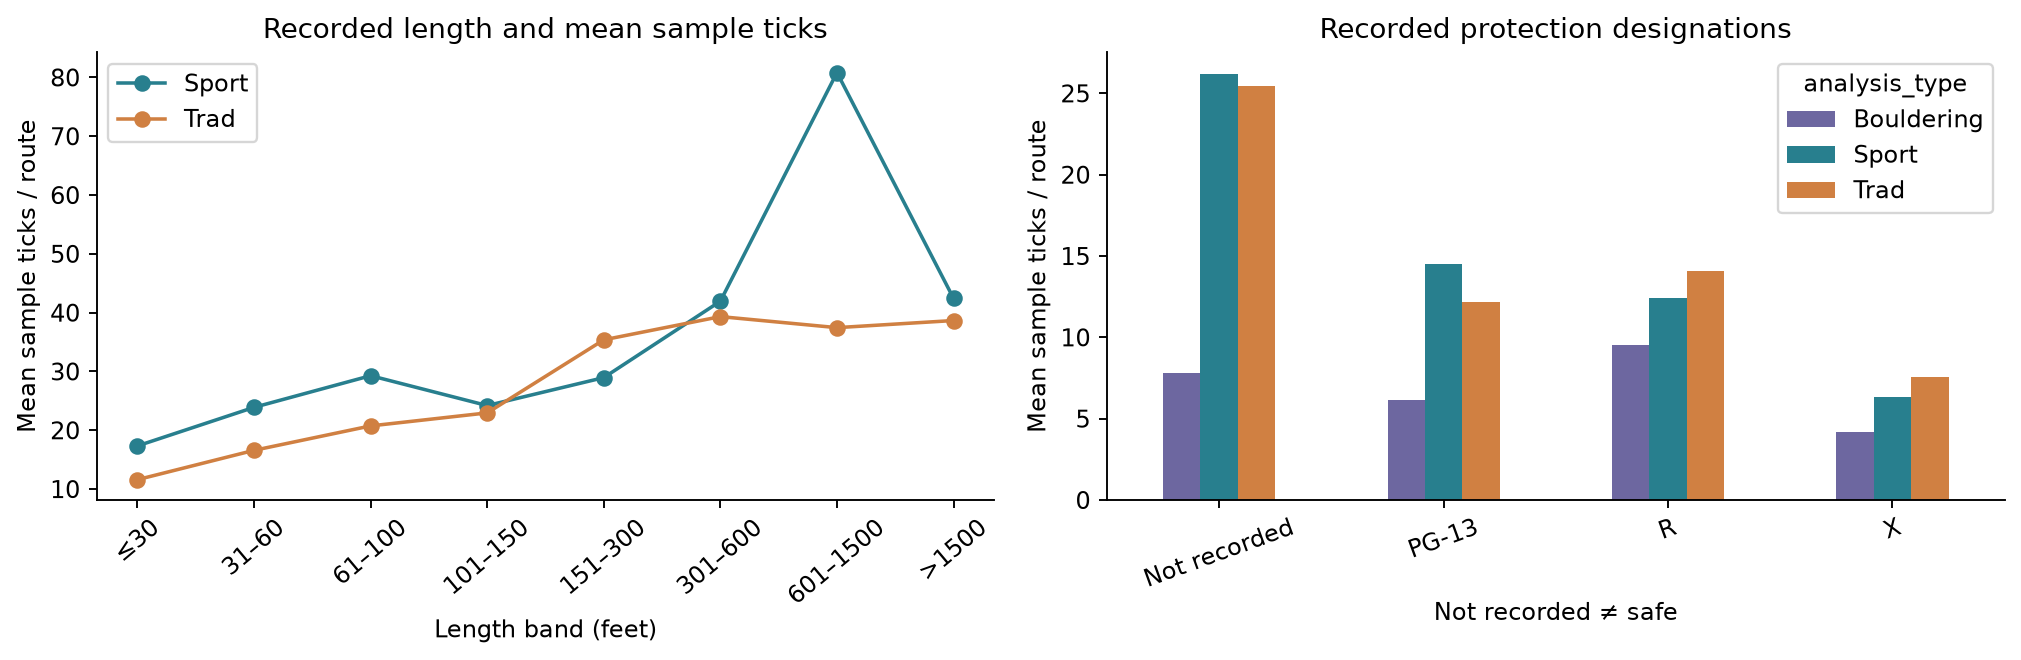

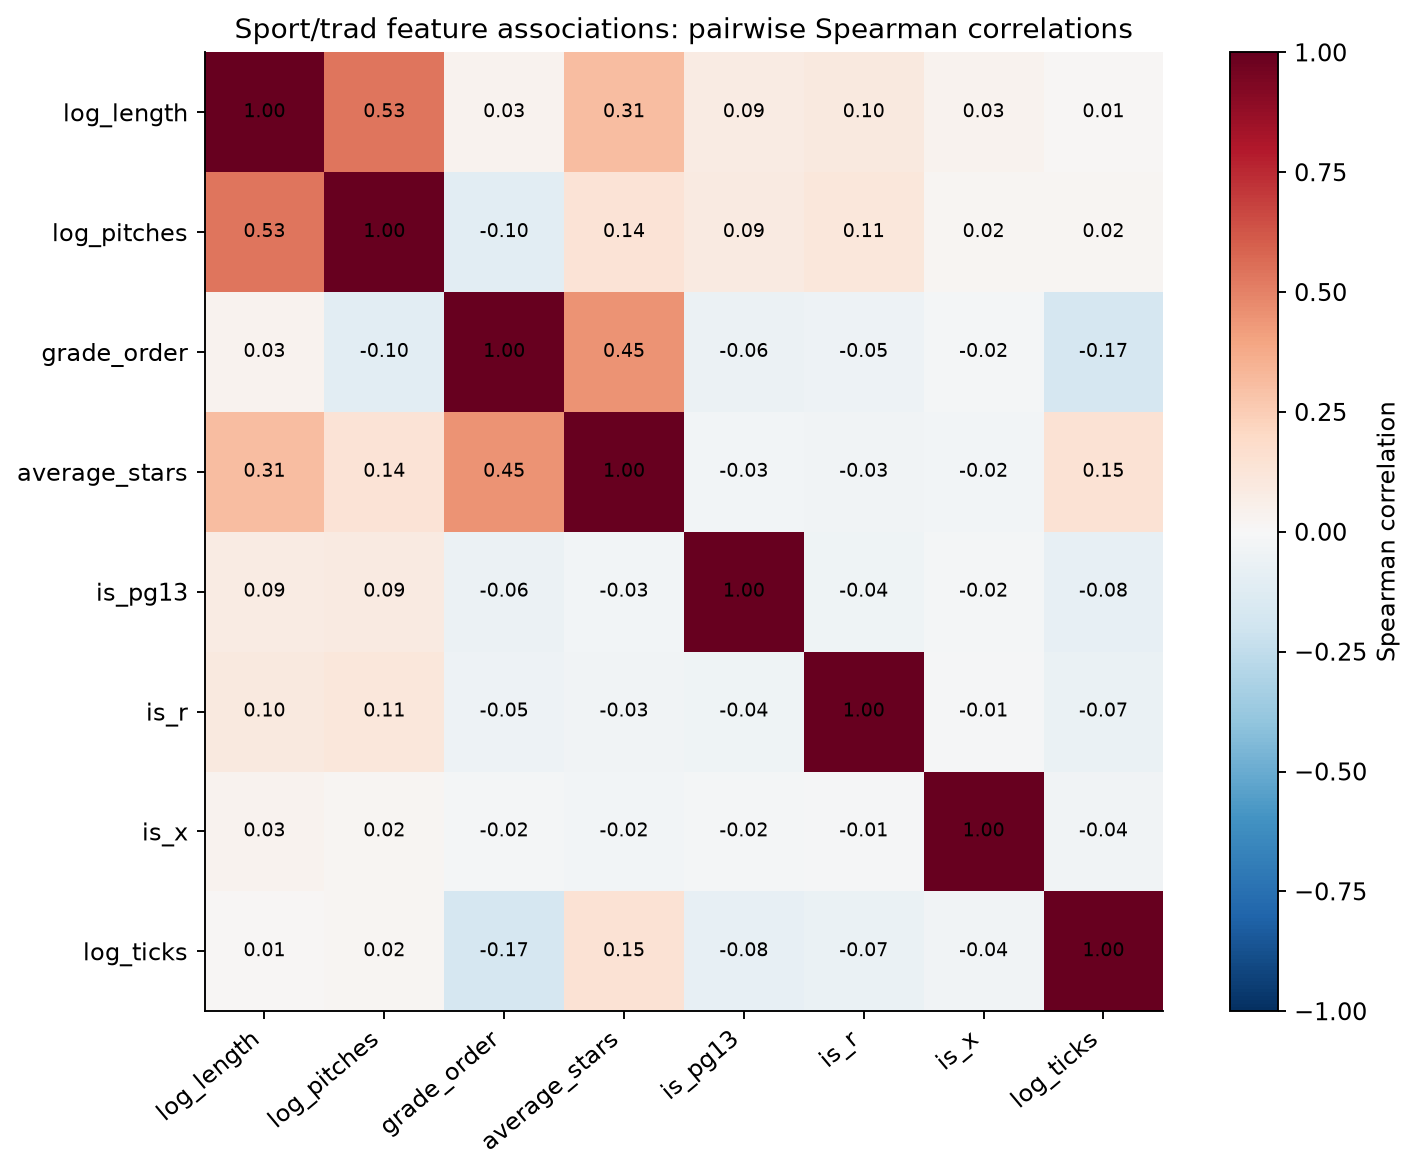

,log_length,log_pitches,grade_order,average_stars,is_pg13,is_r,is_x,log_ticks
feature,,,,,,,,
log_length,61645,61643,61384,61542,61645,61645,61645,61645
log_pitches,61643,70155,69784,70014,70155,70155,70155,70155
grade_order,61384,69784,69791,69656,69791,69791,69791,69791
average_stars,61542,70014,69656,70016,70016,70016,70016,70016
is_pg13,61645,70155,69791,70016,70205,70205,70205,70205
is_r,61645,70155,69791,70016,70205,70205,70205,70205
is_x,61645,70155,69791,70016,70205,70205,70205,70205
log_ticks,61645,70155,69791,70016,70205,70205,70205,70205


In [7]:
display(tables["length_summary"])
display(tables["protection_summary"])
show_figure("04_length_protection")
show_figure("11_feature_correlations")
display(pd.read_csv(eda.OUT / "correlation_pair_counts.csv", index_col=0))

## PCA — route profiles, with popularity as an overlay
We fit PCA to complete sport/trad routes using log length, log pitches, coarse YDS family order, Kaggle stars and three recorded protection flags. These seven features are standardized before PCA. Popularity and geographic coordinates are **not** fitted features. The bouldering scale stays out of this fit.

The left panel is a correlation biplot: standardized component scores and feature/PC correlation arrows, enlarged ×3 for display. The right panel colors the same profile projection by ticks. The plotted points are a reproducible 6,000-route sample; PCA uses all complete eligible records. The view clips scores beyond ±4.5, and the full score export preserves them.

The first two components retain about **48.0%** of feature variance. Arrow relationships are only approximations in that projection. Binary flags and ordinal grade choices affect distances; PCA is descriptive rather than a validated route similarity or safety model. [PCA documentation](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html), [feature scaling](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html).

,eligible,complete_fit,excluded_missing
0,70205,61282,8923


,feature,PC1,PC2,represented_variance_pc1_pc2
0,log_length,0.926869,-0.131685,0.876426
1,log_pitches,0.889396,-0.236513,0.846963
2,grade_order,0.106985,0.843286,0.722578
3,average_stars,0.441517,0.736388,0.737205
4,is_pg13,0.141501,-0.221037,0.068880
5,is_r,0.205268,-0.237767,0.098668
6,is_x,0.031743,-0.089968,0.009102


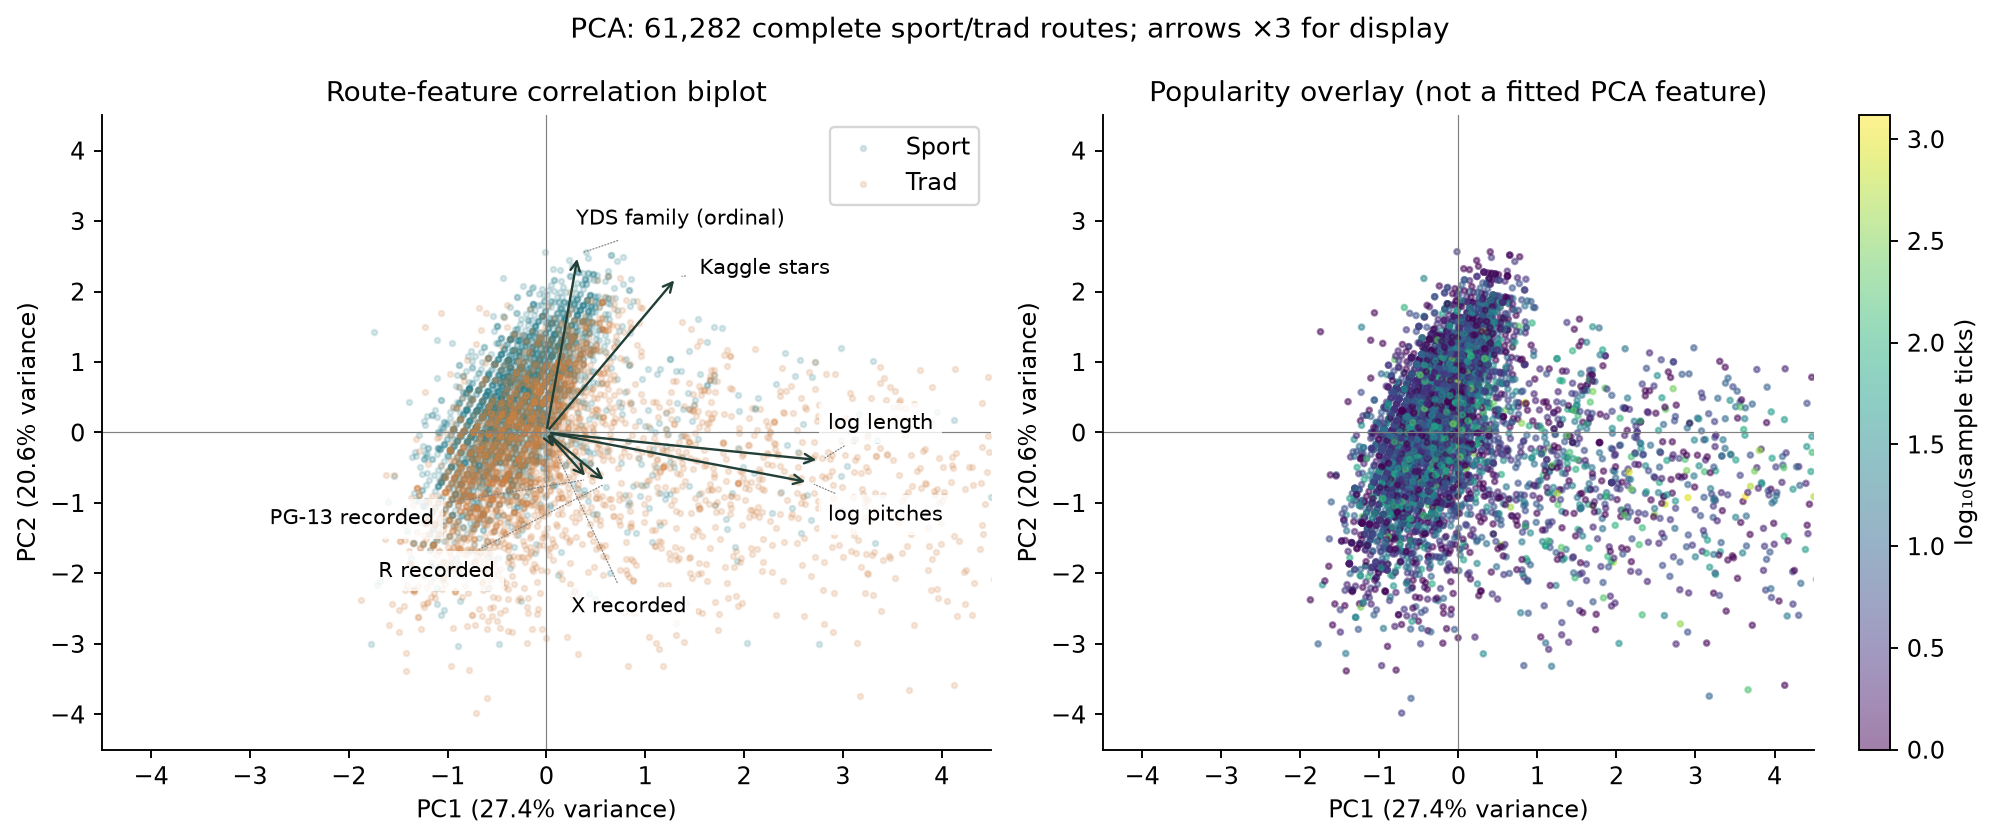

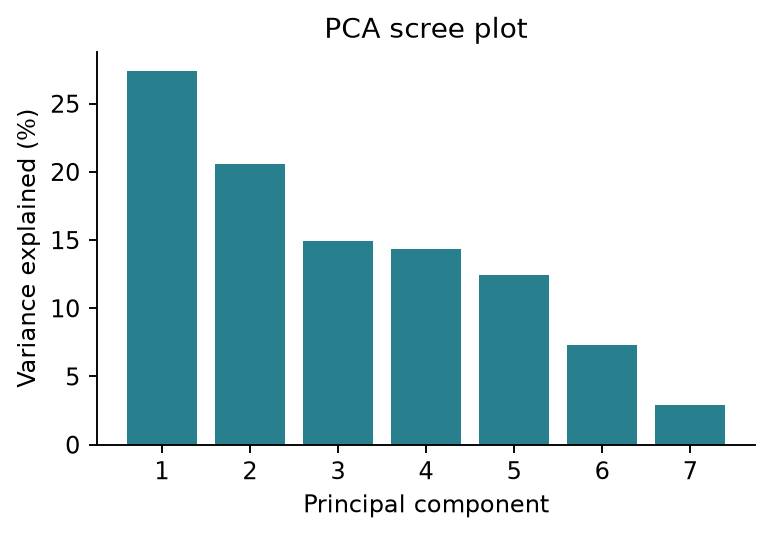

In [8]:
pca_routes, pca_metadata = eda.pca_analysis(data)
display(pd.DataFrame({"eligible": [pca_metadata["eligible_routes"]],
                      "complete_fit": [pca_metadata["fit_routes"]],
                      "excluded_missing": [pca_metadata["complete_case_exclusions"]]}))
loadings = pd.read_csv(eda.OUT / "pca_loadings.csv")
display(loadings)
show_figure("07_pca_biplot")
show_figure("08_pca_scree", width=600)

**Interpretation:** length and pitches point in similar directions and are well represented in the first two components. The protection flags are poorly represented: the two-component representation accounts for only about 6.9% of PG-13, 9.9% of R and 0.9% of X feature variance. Consequently, a short protection arrow is not evidence that protection has no association with popularity. Use the full correlations and regression instead.

## Regression — adjusted associations, not causal effects
Because the joined sample has no zeros and very skewed positive counts, we fit exploratory OLS models of **log(1 + sample ticks)** rather than raw-count linear regression. The target is transformed recorded activity conditional on appearing in the sample. This is not a complete count-generating model; it does not correct sample selection or estimate unobserved zero-count routes.

Sport/trad models include grade-family categories, state categories, type, log length, log pitches and protection flags. A quality extension adds Kaggle stars. Its baseline is refitted on **exactly the same records** so adding stars is not confused with a changed population. Bouldering is modeled separately without fabricated lengths, pitches or quality scores. Rare grade groups (<30 complete routes) are excluded from models and remain in descriptive tables.

Uncertainty intervals cluster by rounded climbing-area coordinates within state, using [statsmodels' clustered covariance](https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.RegressionResults.get_robustcov_results.html). Clustering cannot correct unknown shared users, route age, reporting selection or mixed observation dates. Grade categories avoid assuming equal linear grade steps. R² is **in-sample variance explained in the log outcome**, not forecast accuracy or variance explained in raw tick counts.

,name,eligible_routes,fit_routes,excluded_routes,area_clusters,r_squared,design_rank,design_columns
0,roped_ticks,70205,61377,8828,8517,0.120719,65,65
1,roped_climbers,70205,61377,8828,8517,0.123932,65,65
2,roped_ticks_quality,70205,61277,8928,8510,0.213256,66,66
3,roped_ticks_quality_baseline,70016,61277,8739,8510,0.120842,65,65
4,roped_ticks_ge5,38571,33317,5254,5368,0.096191,59,59
5,roped_ticks_trimmed_length,61617,61359,258,8510,0.120914,65,65
6,roped_ticks_source_grades_only,68575,59962,8613,8454,0.122263,64,64
7,boulder_ticks,26530,26488,42,4476,0.089256,63,63
8,boulder_climbers,26530,26488,42,4476,0.090805,63,63


,model,term,coefficient,ci_low,ci_high,p_value,percent_change_in_geometric_count_plus_one
0,roped_ticks_quality_baseline,log_length,0.156604,0.117453,0.195754,5.009542e-15,16.953194
1,roped_ticks_quality_baseline,log_pitches,0.031665,-0.032890,0.096220,3.363167e-01,3.217169
2,roped_ticks_quality_baseline,is_pg13,-0.454584,-0.504935,-0.404234,7.387818e-69,-36.528829
3,roped_ticks_quality_baseline,is_r,-0.444669,-0.500730,-0.388608,8.925813e-54,-35.896334
4,roped_ticks_quality_baseline,is_x,-0.619612,-0.747642,-0.491583,3.033809e-21,-46.184704
5,roped_ticks_quality,log_length,-0.123210,-0.161885,-0.084535,4.442303e-10,-11.592198
6,roped_ticks_quality,log_pitches,0.165464,0.103994,0.226935,1.348933e-07,17.994079
7,roped_ticks_quality,is_pg13,-0.353177,-0.400379,-0.305975,4.038665e-48,-29.754713
8,roped_ticks_quality,is_r,-0.289904,-0.343052,-0.236757,1.623546e-26,-25.166481
9,roped_ticks_quality,is_x,-0.414992,-0.541199,-0.288784,1.213857e-10,-33.965416


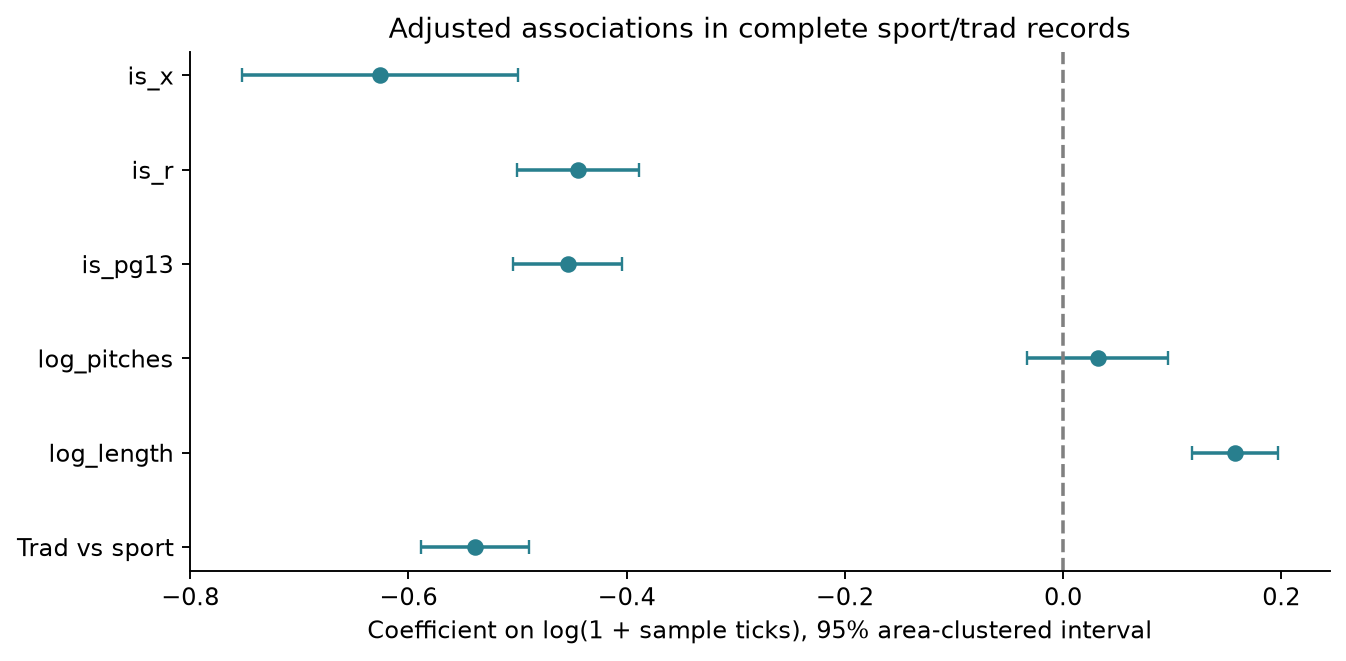

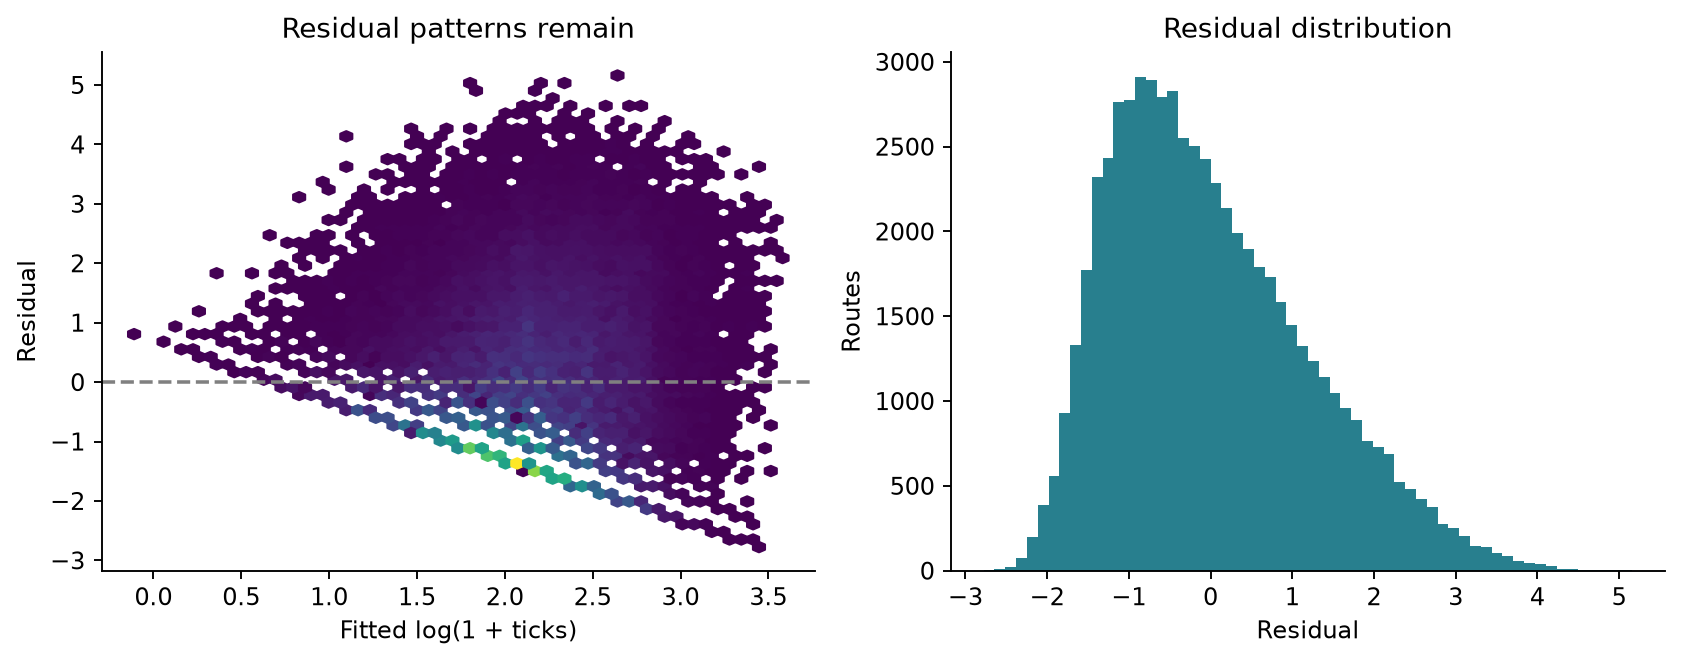

In [9]:
models = eda.regression_analysis(data)
comparison = pd.DataFrame(models)
display(comparison[["name", "eligible_routes", "fit_routes", "excluded_routes", "area_clusters", "r_squared", "design_rank", "design_columns"]])
assert comparison.design_rank.eq(comparison.design_columns).all()
terms = ["log_length", "log_pitches", "is_pg13", "is_r", "is_x", "average_stars"]
coefficient_tables = []
for name in ["roped_ticks_quality_baseline", "roped_ticks_quality", "roped_climbers"]:
    table = pd.read_csv(eda.OUT / f"regression_{name}.csv")
    table = table.loc[table.term.isin(terms)].copy()
    table.insert(0, "model", name)
    coefficient_tables.append(table)
display(pd.concat(coefficient_tables, ignore_index=True))
show_figure("09_regression_coefficients")
show_figure("10_regression_diagnostics")

**Finding:** the complete sport/trad tick model explains about 12.1% of log-outcome variance; the quality extension explains about 21.3%. Its matching baseline uses the same 61,277 routes. The length coefficient changes from positive without stars to negative with stars. Recorded PG-13/R/X designations have negative adjusted associations in these models. These results support a nuanced account of popularity rather than a causal claim about length, protection or quality. Quality ratings can also be influenced by who visits and rates routes.

Residual patterns remain. The models are interpretable EDA summaries, not validated prediction engines. Formal p-values are exploratory and are not adjusted for multiple comparisons; focus on effect sizes, uncertainty, sample composition and stability.

## Sensitivity checks
Compare ticks versus distinct sampled climbers; at least five ticks and at least five climbers; Kaggle-only records; exclusion of archive-resolved grades; and exclusion of roped lengths above 3,000 feet. These are alternative populations, not improvements guaranteed to remove bias. Five-record/climber thresholds truncate the popularity outcome and can change mean-grade rankings. The full population remains the main result.

In [10]:
sensitivity = eda.sensitivity_analysis(data)
display(pd.DataFrame(sensitivity))
length_effects = []
for name in ["roped_ticks_quality_baseline", "roped_ticks_quality", "roped_ticks_trimmed_length", "roped_ticks_source_grades_only"]:
    table = pd.read_csv(eda.OUT / f"regression_{name}.csv")
    row = table.loc[table.term.eq("log_length")].iloc[0]
    length_effects.append({"model": name, "length_coefficient": row.coefficient,
                           "doubling_length_association_geometric_count_plus_one_pct": 100 * np.expm1(row.coefficient * np.log(2)),
                           "ci_low": row.ci_low, "ci_high": row.ci_high})
display(pd.DataFrame(length_effects))
eda.export_web(data, pca_routes, pca_metadata)

,population,type,routes,ticks_climbers_spearman,grade_most_total_ticks,grade_highest_mean_ticks_ge30_routes
0,All core rock,Sport,36856,0.995707,5.10,5.7
1,All core rock,Trad,33349,0.993241,5.10,5.6
2,All core rock,Bouldering,26530,0.989778,V0,V1
3,At least 5 sample ticks,Sport,22054,0.991681,5.10,5.3
4,At least 5 sample ticks,Trad,16517,0.988434,5.10,5.6
5,At least 5 sample ticks,Bouldering,8422,0.982380,V0,V4
6,At least 5 sampled climbers,Sport,21540,0.992980,5.10,5.3
7,At least 5 sampled climbers,Trad,15992,0.991283,5.10,5.6
8,At least 5 sampled climbers,Bouldering,8080,0.987775,V0,V4
9,Kaggle only,Sport,36856,0.995707,5.10,5.7


,model,length_coefficient,doubling_length_association_geometric_count_plus_one_pct,ci_low,ci_high
0,roped_ticks_quality_baseline,0.156604,11.465992,0.117453,0.195754
1,roped_ticks_quality,-0.123210,-8.185747,-0.161885,-0.084535
2,roped_ticks_trimmed_length,0.164401,12.070049,0.124449,0.204353
3,roped_ticks_source_grades_only,0.158405,11.605294,0.119046,0.197765


Tick and distinct-climber route rankings are strongly related (Spearman correlations above 0.98 within all three styles), but they remain different quantities. Total-grade leaders stay 5.10/5.10/V0 in the five-record and five-climber comparisons; some per-route mean leaders change. Kaggle-only bouldering has only 59 classified routes, so it is not an adequate substitute for the full bouldering population.

## Conclusions and practical limits
1. Grade-family activity volume peaks at 5.10 for sport/trad and V0 for bouldering, while per-route averages tell a different story.
2. Geographic tick volume and style share vary, but source coverage and route availability accompany every comparison.
3. Length, quality and recorded protection relate to sampled activity, with the length association sensitive to quality adjustment. PCA explains profile structure, not popularity effects.

The strongest limits are sample selection, capped user histories, ambiguous repeats, absent individual dates, unknown route age/access, missing bouldering measurements, and mixed feature snapshots. Findings apply to retained historical records and should not be generalized to all climbers or current traffic. Unmatched routes cannot be assigned zero ticks. No personalized recommender is built.

## Deliverables and collaboration
The notebook, Python modules, figures, coefficient/coverage tables and interactive explorer form the analytical package. The final PDF must use the Canvas team name, be at most 11 pages and accompany the notebooks/modules in a ZIP. The final statement of work, collaboration reflection, actual meeting/check-in evidence, and any required AI-assistance disclosure need team confirmation before submission; they are not fabricated here.

The atlas is a tested local companion prepared for Base44 integration. Actual Base44 hosting requires the connected integration and a verified deployment URL.